Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


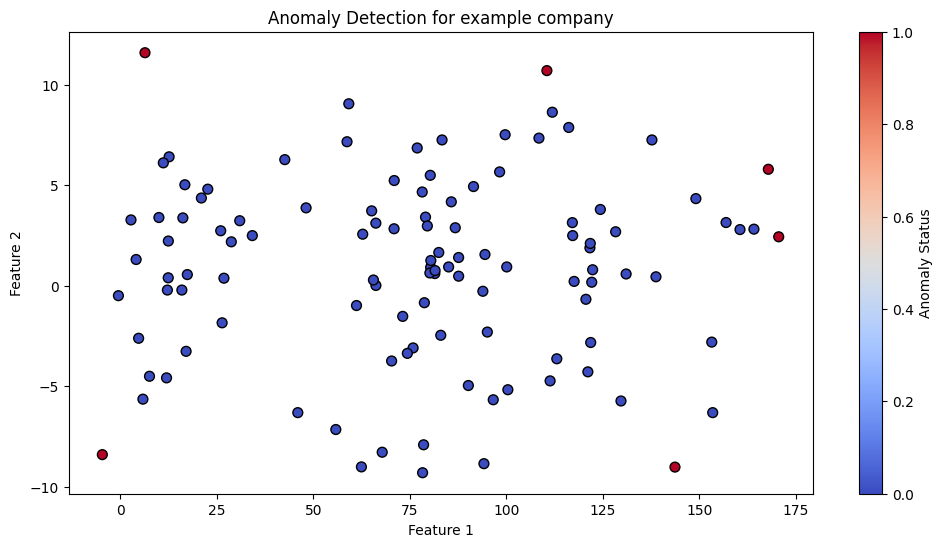

In [9]:
# Ensure dependencies are installed
%pip install pandas openpyxl matplotlib scikit-learn seaborn matplotlib-venn

from google.colab import drive
drive.mount('/content/drive')

# Import required libraries
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set up file paths
drive_dir = r'/content/drive/My Drive'
file_path = os.path.join(drive_dir, 'DatasetsCombinedCommonPeriodMatrix.xlsx')

try:
    # Load the Excel file
    data = pd.read_excel(file_path)

    # Step 1: Identify company columns based on prefixes
    company_columns = {}
    for col in data.columns:
        if ".PortfolioReturnMatrix" in col:
            prefix = col.split(".")[0]
            company_columns.setdefault(prefix, []).append(col)

    # Step 2: Preprocess and Analyze each company's data
    summary = {"Company": [], "Total Records": [], "Anomalies Detected": []}
    anomaly_results = {}

    for company, columns in company_columns.items():
        # Extract company data and drop missing values
        company_data = data[columns].dropna()

        # Standardize the data
        scaler = StandardScaler()
        scaled_data = scaler.fit_transform(company_data)

        # Apply Isolation Forest
        isolation_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
        anomaly_scores = isolation_forest.fit_predict(scaled_data)

        # Identify anomalies
        anomalies = (anomaly_scores == -1)
        anomaly_score_values = isolation_forest.decision_function(scaled_data)

        # Save results for each company
        anomaly_results[company] = {
            "data": company_data,
            "anomalies": anomalies,
            "anomaly_scores": anomaly_score_values,
        }

        # Summarize results
        summary["Company"].append(company)
        summary["Total Records"].append(len(company_data))
        summary["Anomalies Detected"].append(sum(anomalies))

    # Step 3: Output Summary
    summary_df = pd.DataFrame(summary)

    # Step 4: Visualization for One Example Company
    example_company = list(company_columns.keys())[0]
    company_data = anomaly_results[example_company]["data"]
    anomalies = anomaly_results[example_company]["anomalies"]
    anomaly_scores = anomaly_results[example_company]["anomaly_scores"]

    # Create a scatter plot of the first two variables
    plt.figure(figsize=(12, 6))
    plt.scatter(company_data.iloc[:, 0], company_data.iloc[:, 1], c=anomalies, cmap="coolwarm", edgecolor="k", s=50)
    plt.title(f"Anomaly Detection for example company")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.colorbar(label="Anomaly Status")
    plt.show()

except FileNotFoundError as e:
    print(f"Error: {e}. Verify the file path and re-run.")


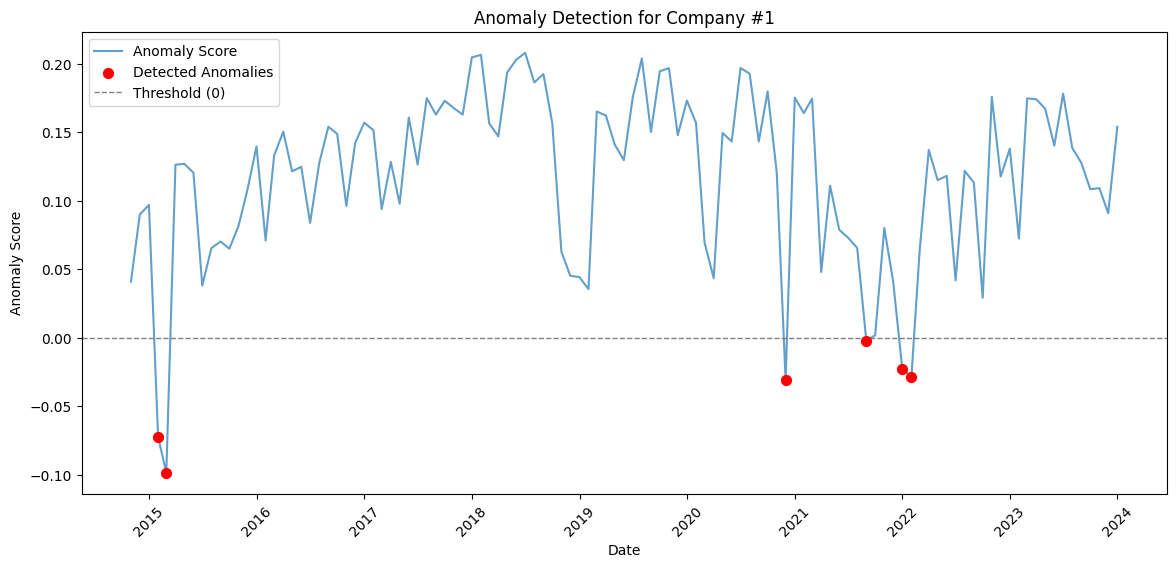

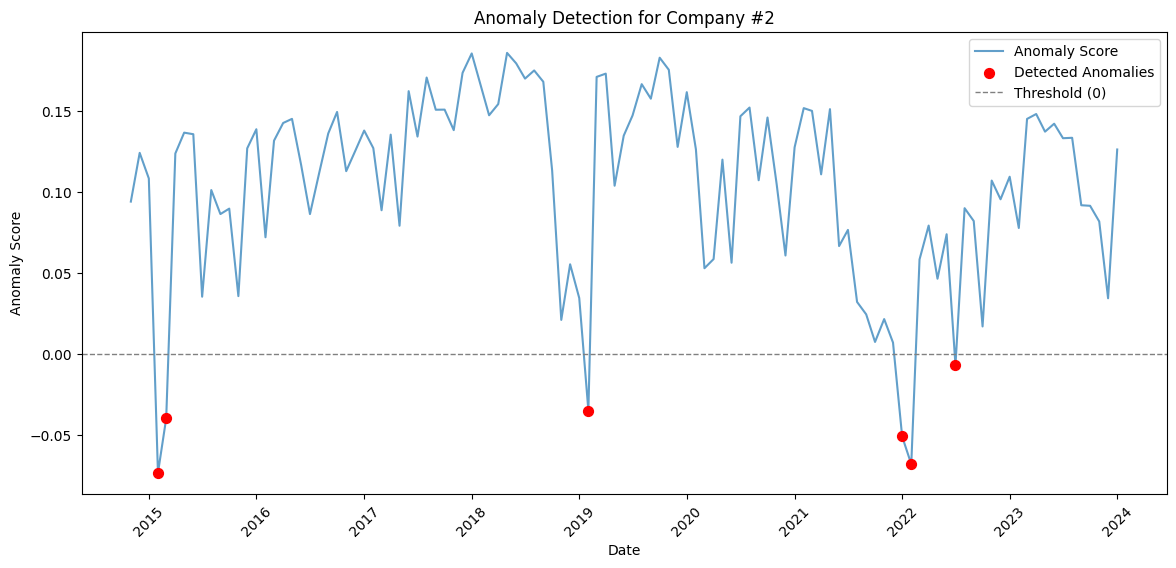

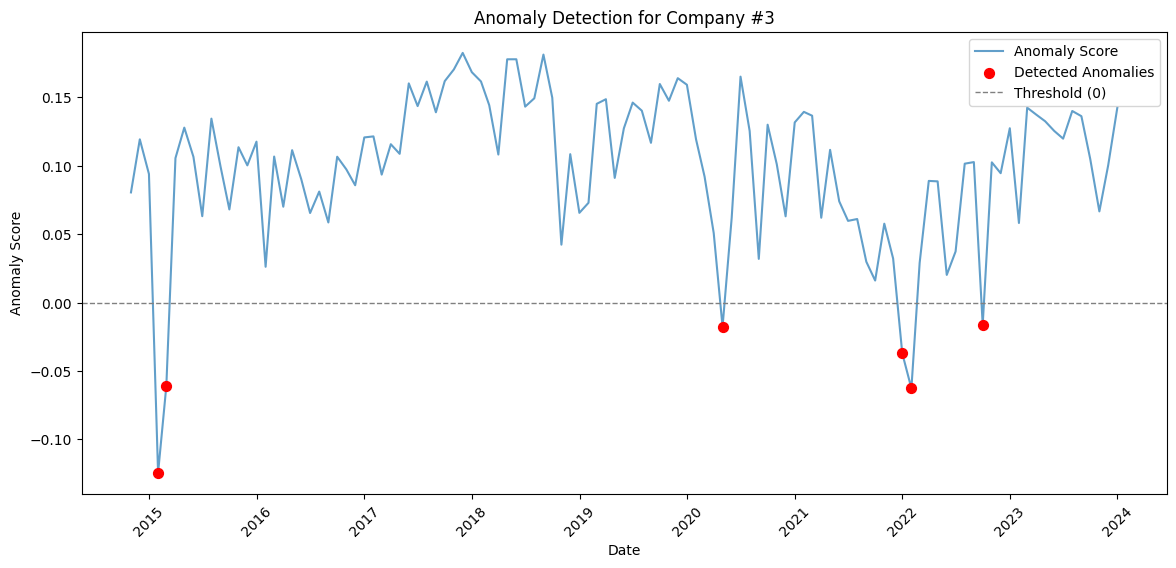

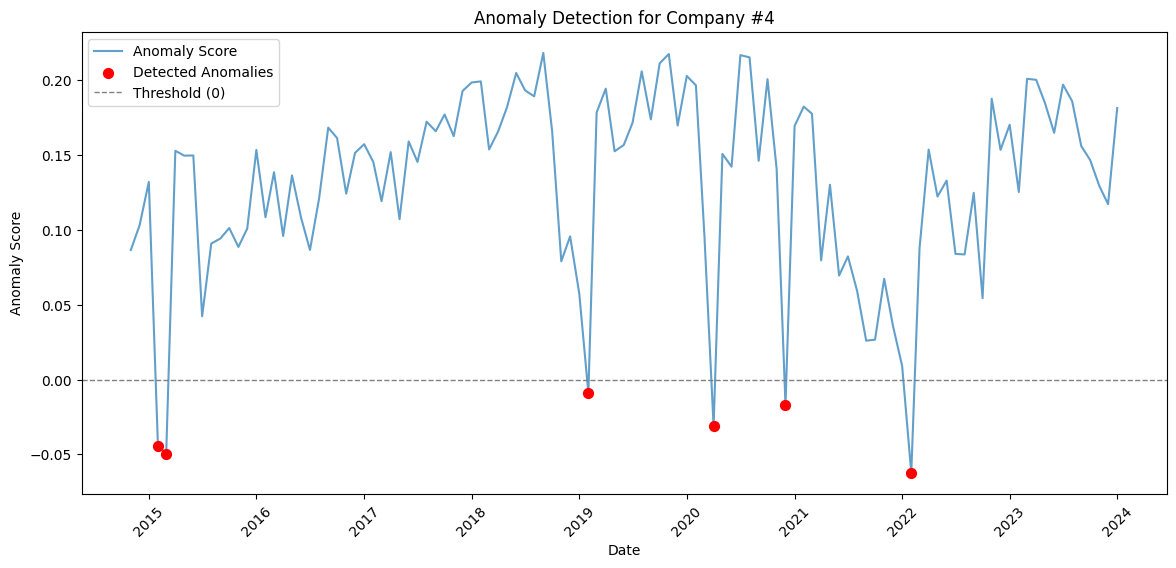

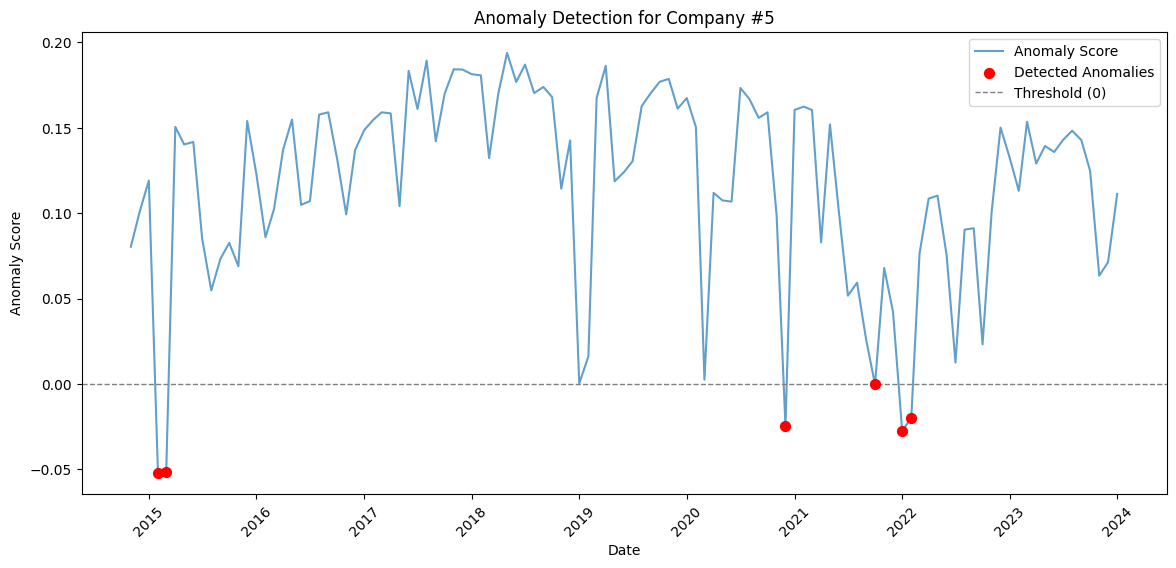

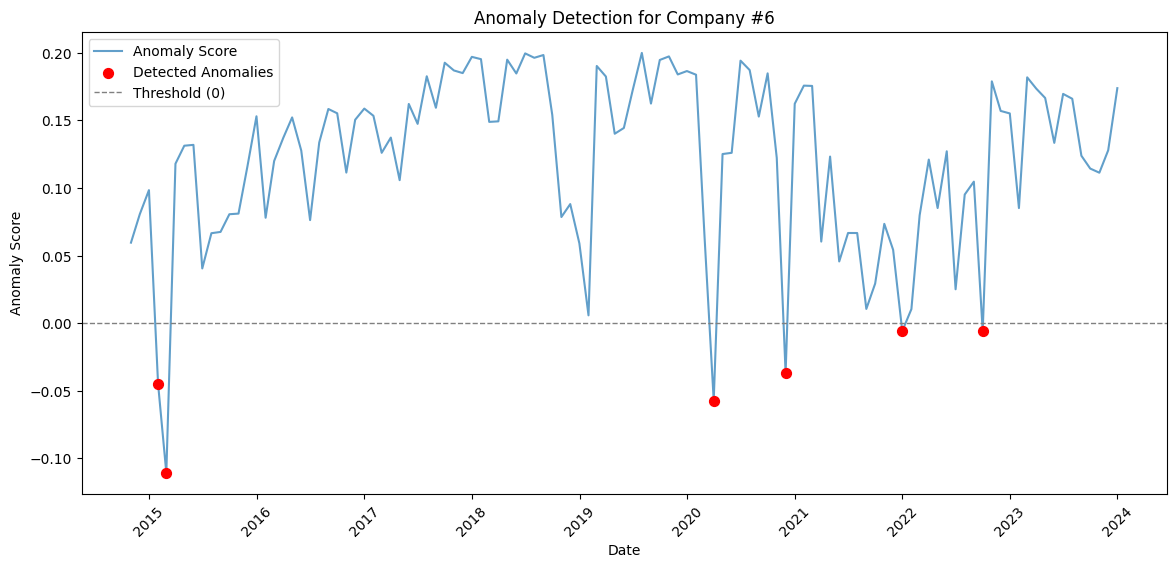

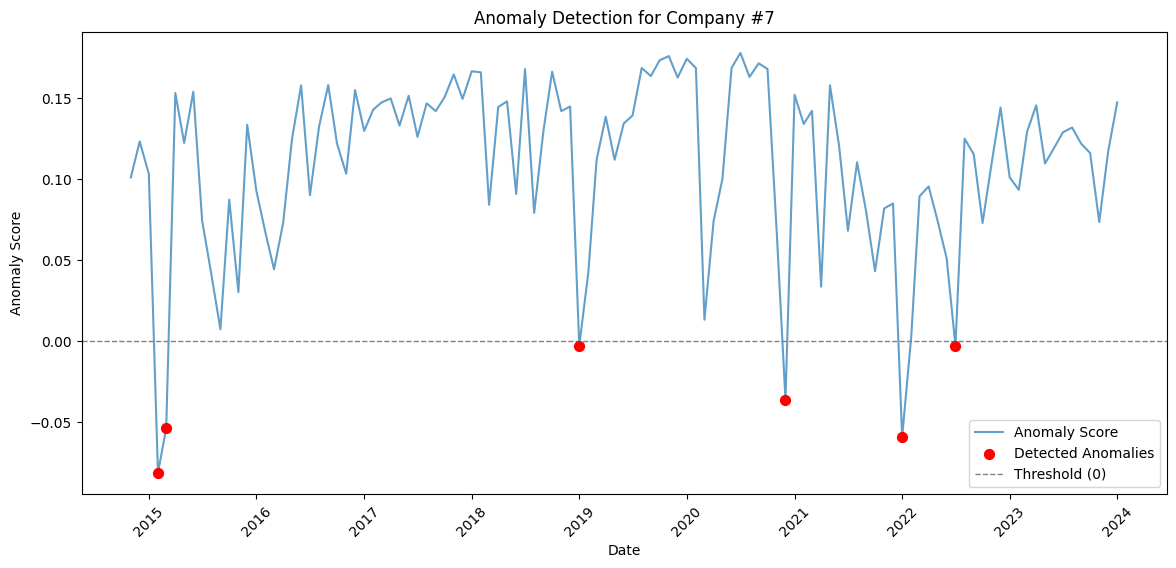

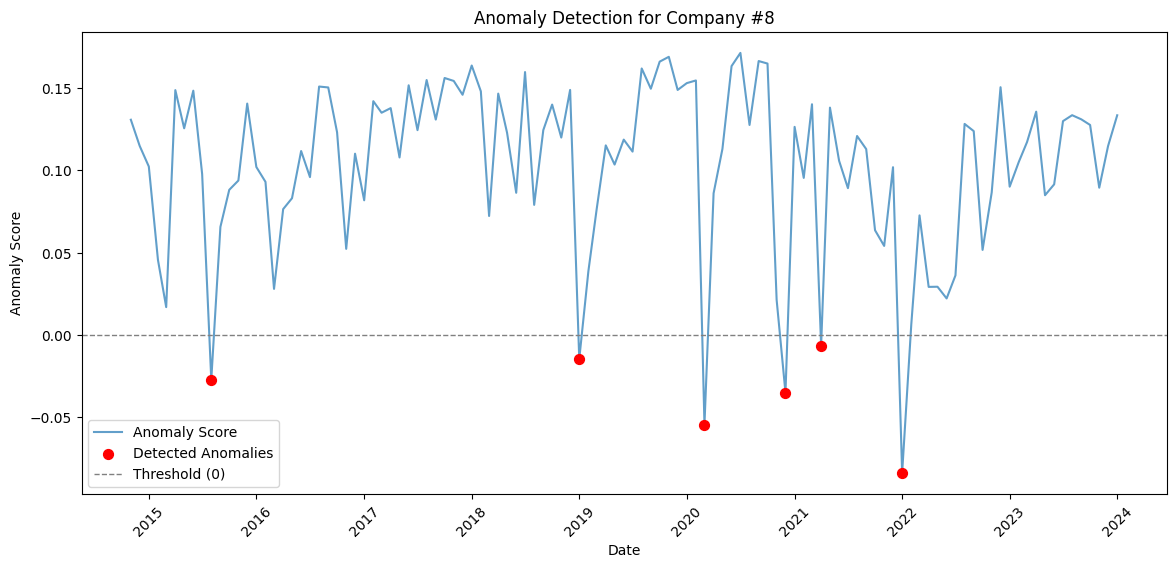

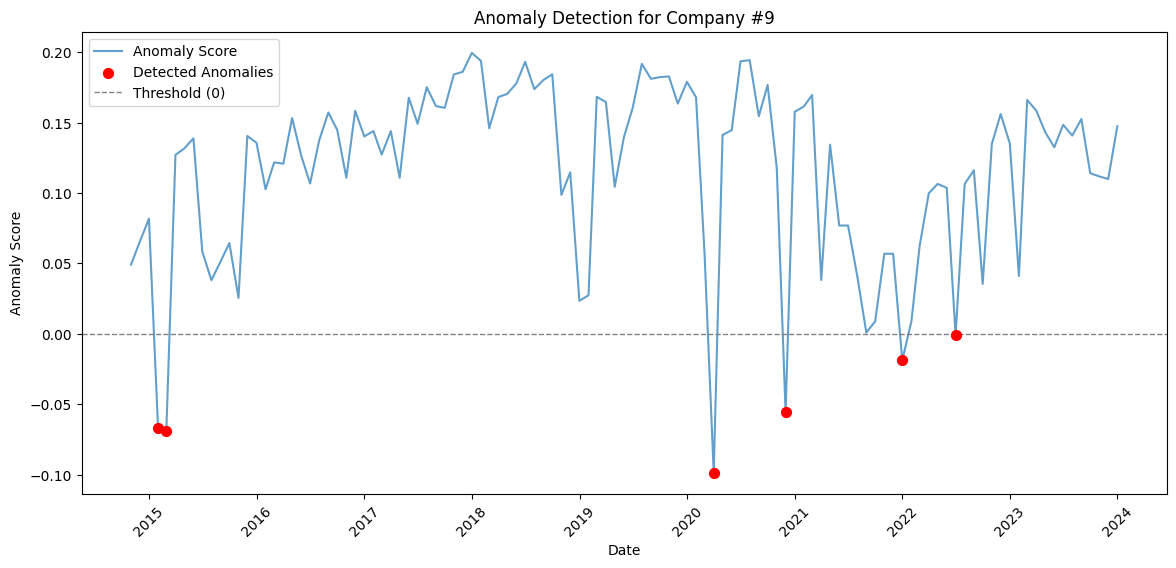

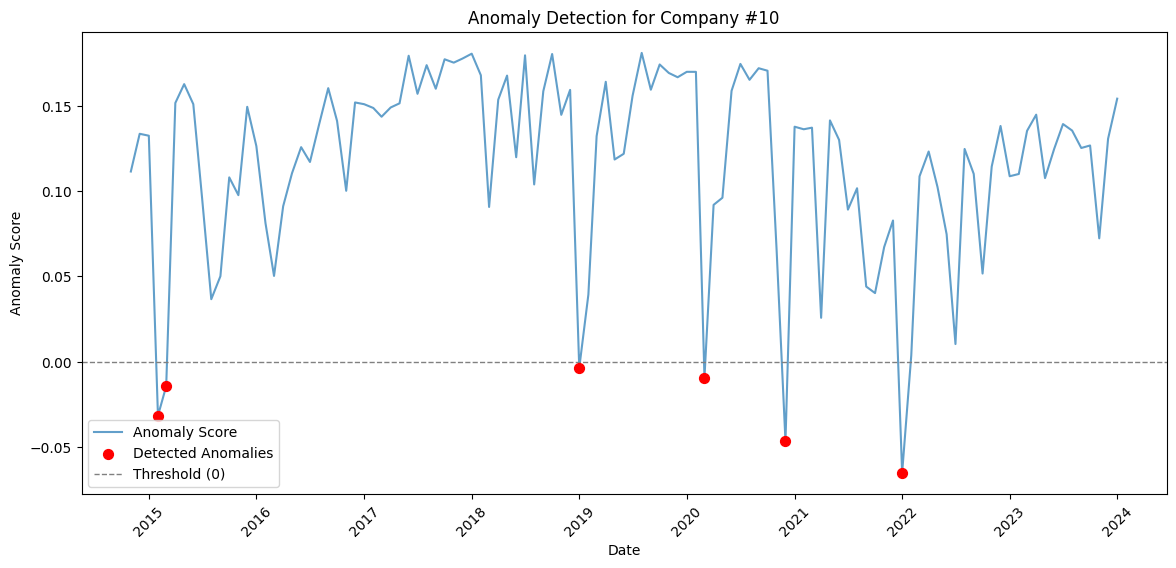

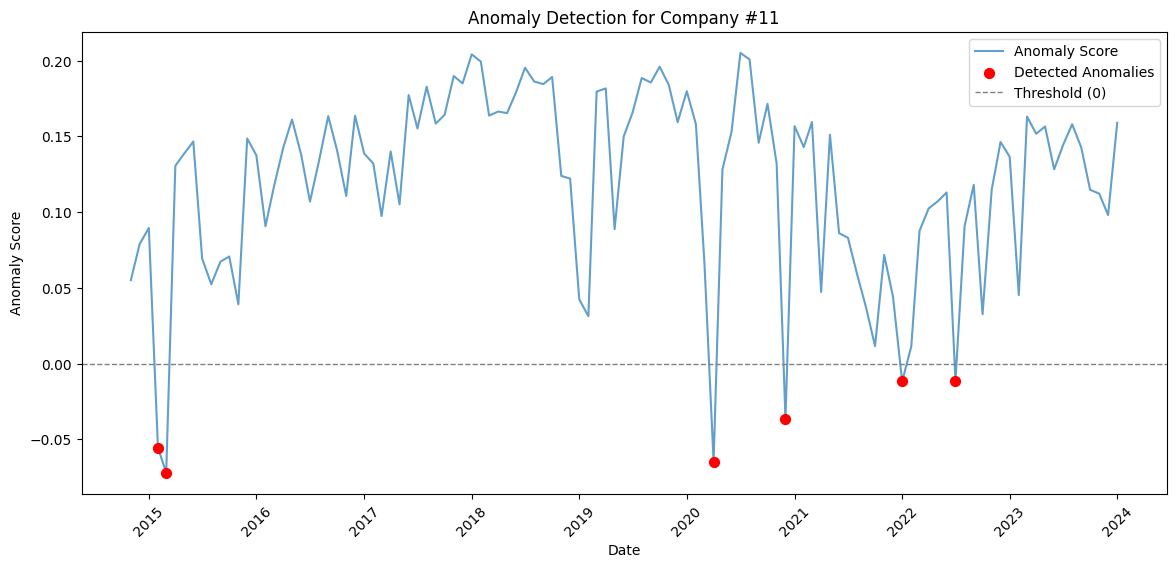

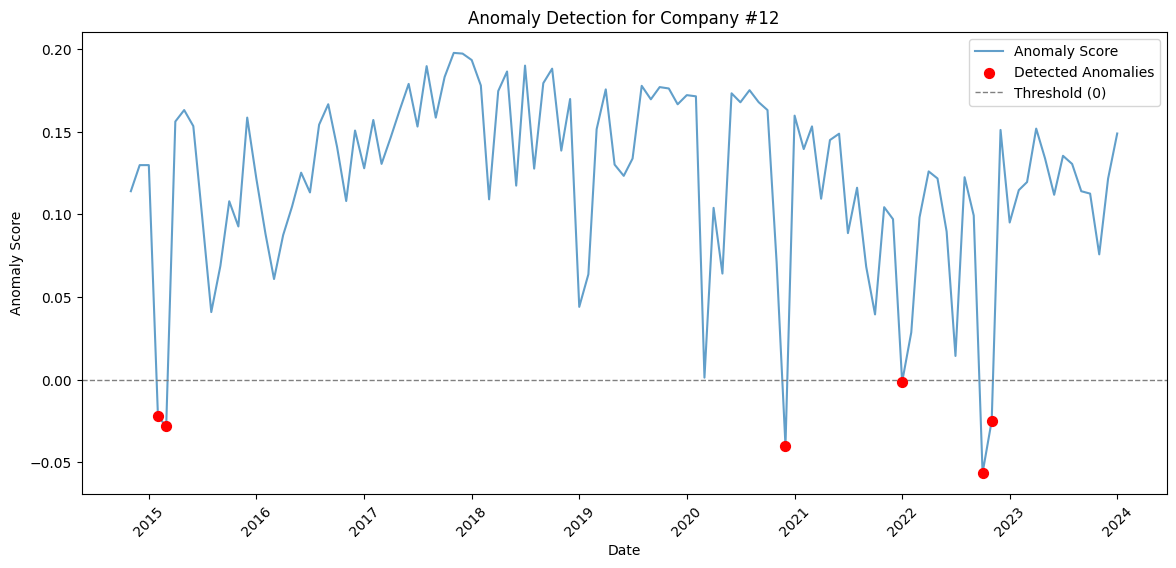

In [10]:
for company, results in anomaly_results.items():
    # Dynamically calculate the company index
    company_index = list(company_columns.keys()).index(company) + 1  # Adding 1 for human-readable indexing

    # Extract company data and anomaly results
    company_data = results["data"]
    anomaly_scores = results["anomaly_scores"]
    anomalies = results["anomalies"]

    # Ensure the Date column is included
    date_column = data["Date"].iloc[company_data.index]  # Extract matching Date values

    # Create a DataFrame for plotting
    plot_data = pd.DataFrame({
        "Date": date_column,
        "Anomaly Score": anomaly_scores,
        "Anomaly": anomalies
    })

    # Line plot for anomaly scores
    plt.figure(figsize=(14, 6))
    plt.plot(plot_data["Date"], plot_data["Anomaly Score"], label="Anomaly Score", alpha=0.7)

    # Highlight anomalies
    anomaly_points = plot_data[plot_data["Anomaly"] == True]
    plt.scatter(anomaly_points["Date"], anomaly_points["Anomaly Score"],
                color="red", label="Detected Anomalies", s=50, zorder=5)

    # Add labels, title, and legend
    plt.title(f"Anomaly Detection for Company #{company_index}")  # Updated title with dynamic index
    plt.xlabel("Date")
    plt.ylabel("Anomaly Score")
    plt.axhline(0, color="gray", linestyle="--", linewidth=1, label="Threshold (0)")
    plt.xticks(rotation=45)
    plt.legend()
    plt.show()


In [11]:
from sklearn.neighbors import LocalOutlierFactor

# Apply LOF for each company
for company, columns in company_columns.items():
    company_data = data[columns].dropna()
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(company_data)

    # Fit LOF model
    lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
    lof_labels = lof.fit_predict(scaled_data)
    lof_scores = -lof.negative_outlier_factor_  # Higher scores indicate more abnormal points

    # Save LOF results
    anomaly_results[company]["LOF_labels"] = lof_labels
    anomaly_results[company]["LOF_scores"] = lof_scores


In [12]:

from sklearn.svm import OneClassSVM

# Apply One-Class SVM for each company
for company, columns in company_columns.items():
    company_data = data[columns].dropna()
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(company_data)

    # Fit One-Class SVM
    oc_svm = OneClassSVM(kernel="rbf", gamma=0.1, nu=0.05)
    oc_svm_labels = oc_svm.fit_predict(scaled_data)
    oc_svm_scores = oc_svm.decision_function(scaled_data)

    # Save One-Class SVM results
    anomaly_results[company]["SVM_labels"] = oc_svm_labels
    anomaly_results[company]["SVM_scores"] = oc_svm_scores


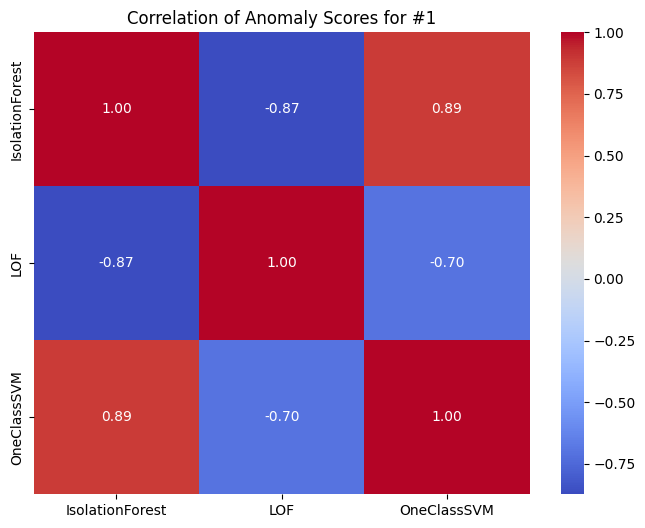

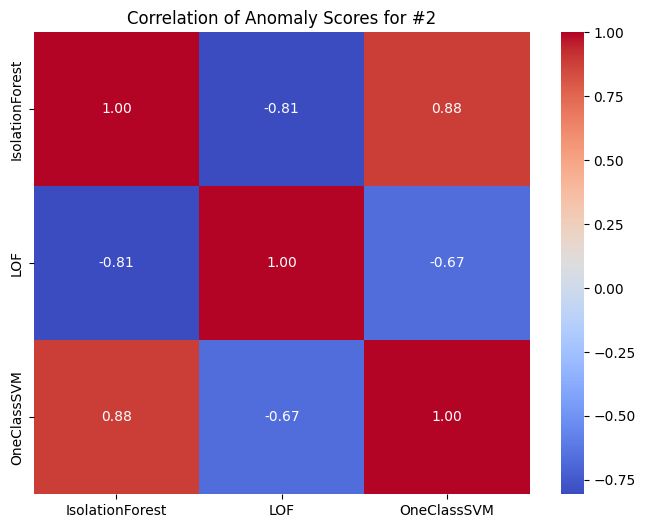

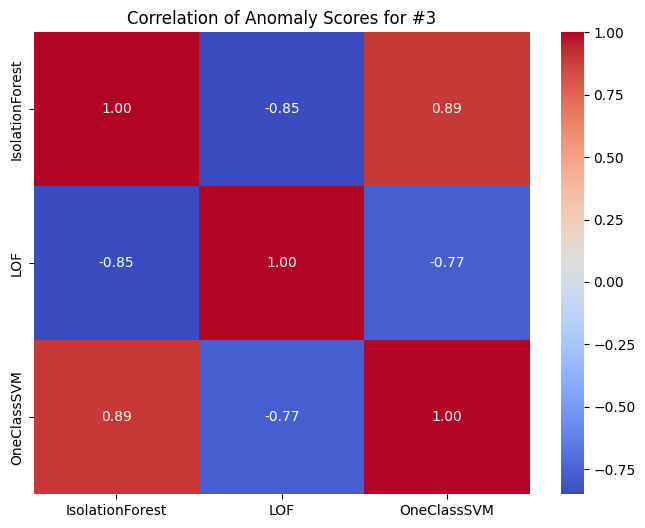

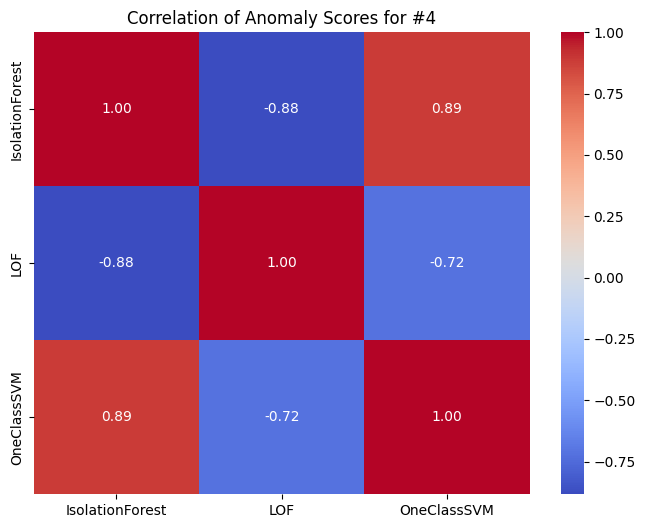

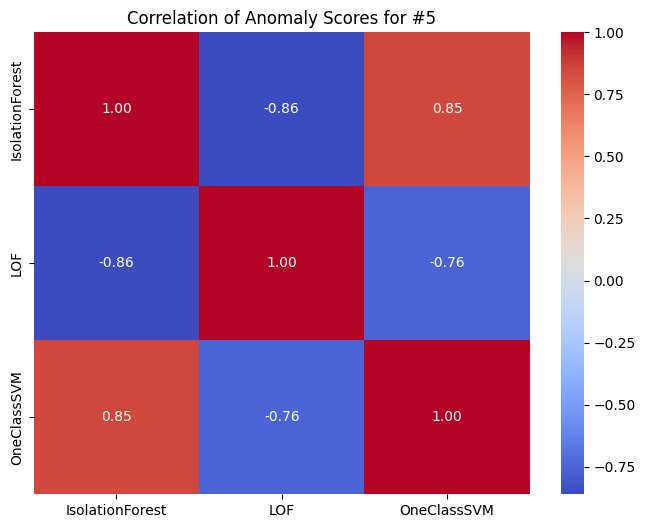

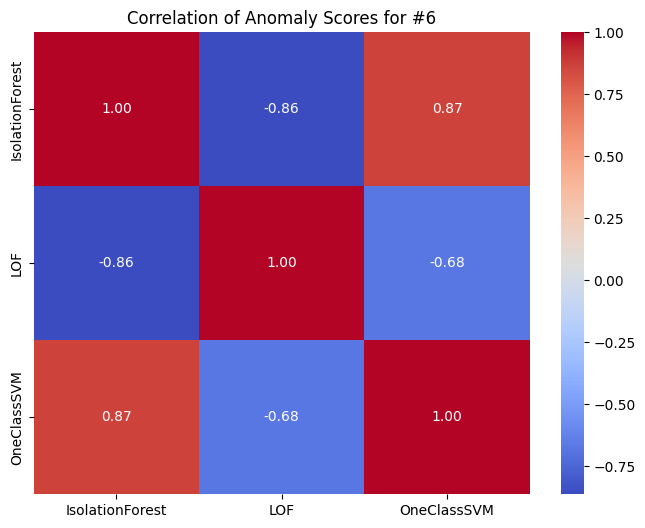

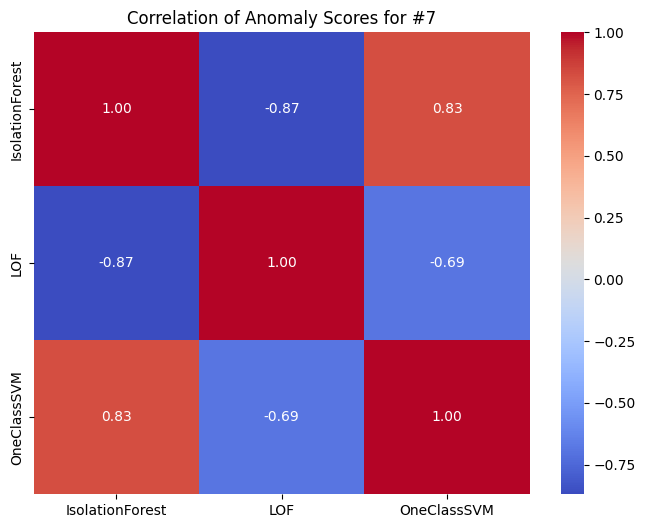

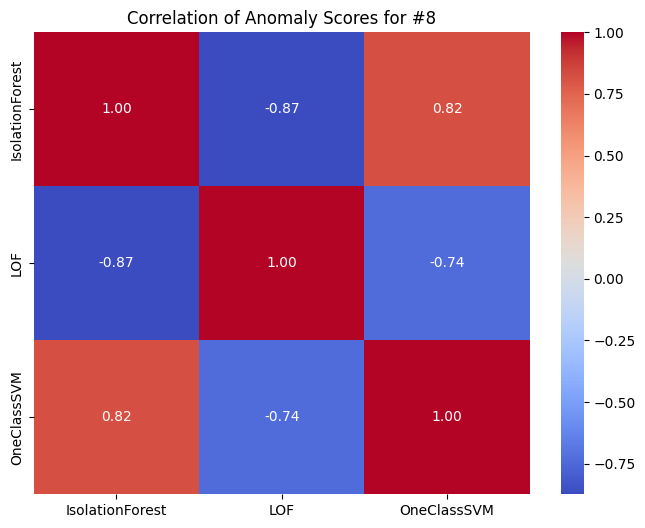

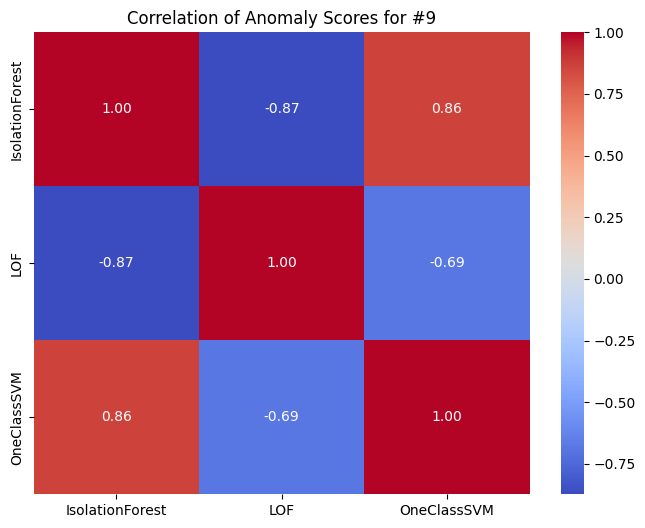

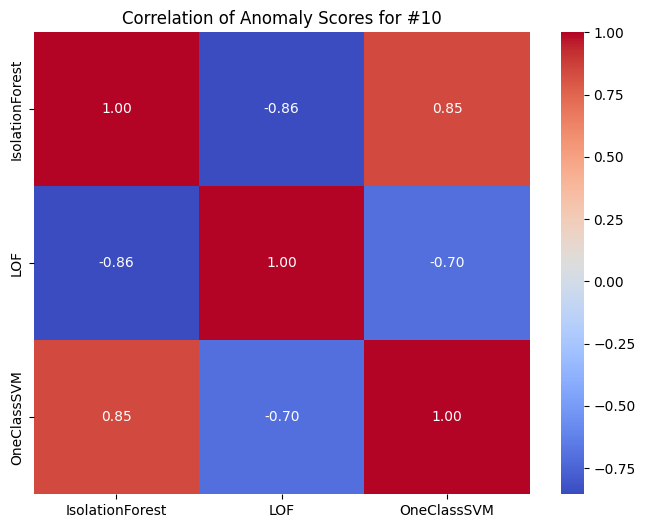

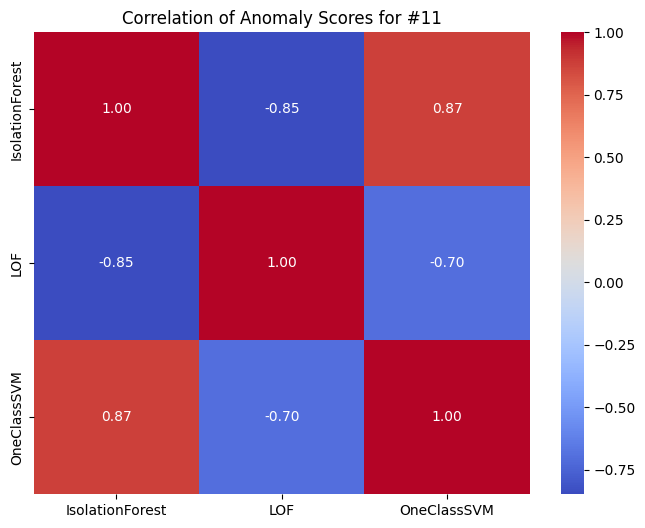

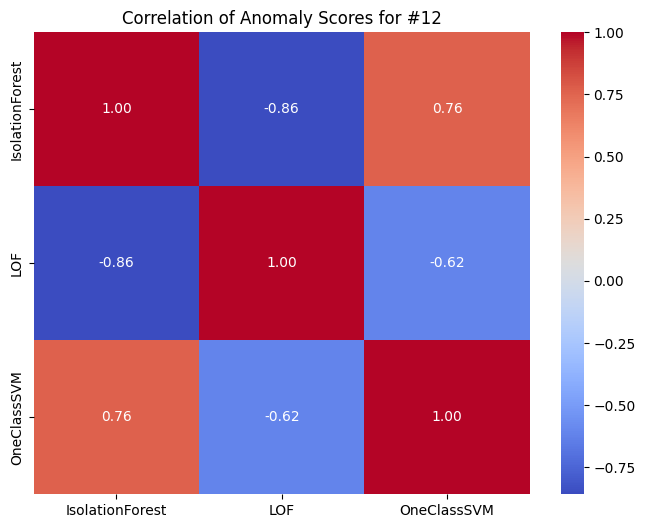

In [13]:
for company, results in anomaly_results.items():
      # Dynamically calculate the company index
    company_index = list(company_columns.keys()).index(company) + 1  # Adding 1 for human-readable indexing
    scores_df = pd.DataFrame({
        "IsolationForest": results["anomaly_scores"],
        "LOF": results["LOF_scores"],
        "OneClassSVM": results["SVM_scores"]
    })

    # Plot correlation heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(scores_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
    plt.title(f"Correlation of Anomaly Scores for #{company_index}")
    plt.show()

/usr/local/lib/python3.10/dist-packages/matplotlib_venn/layout/venn3/pairwise.py:169: UserWarning: Bad circle positioning.
  warnings.warn("Bad circle positioning.")


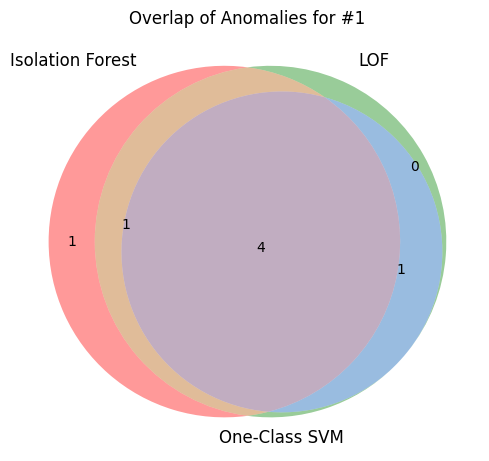

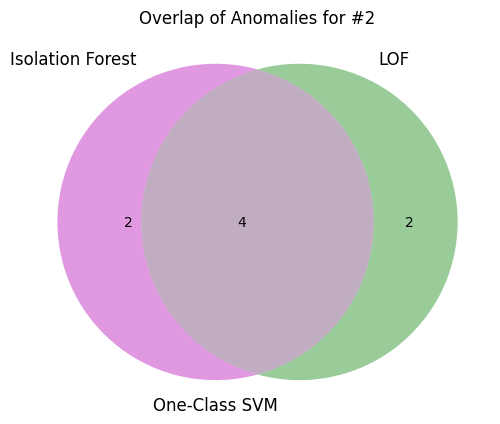

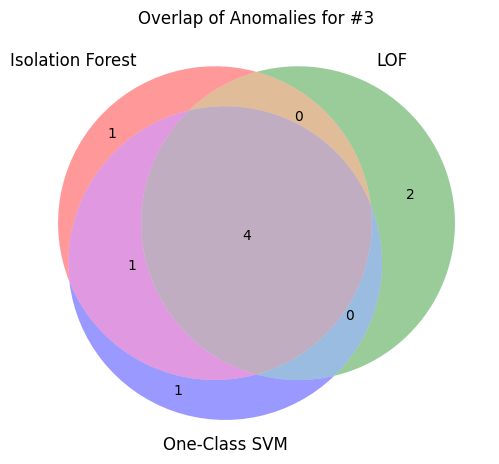

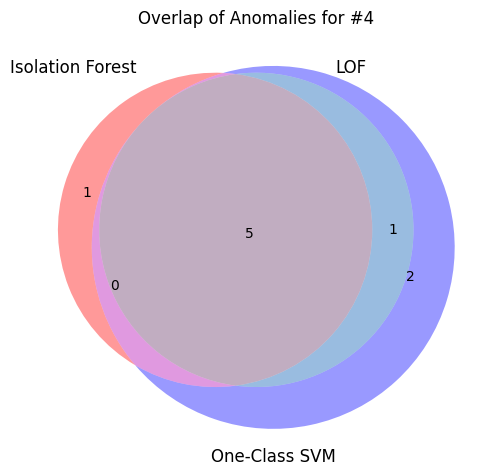

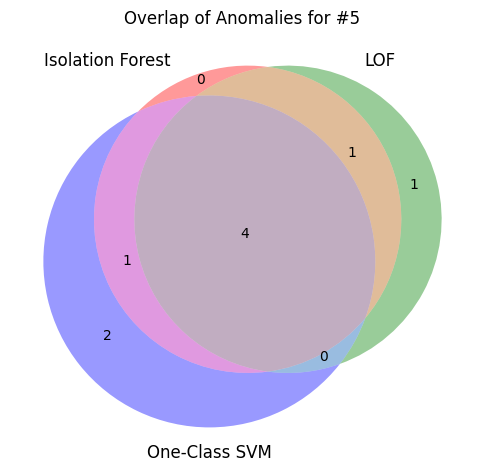

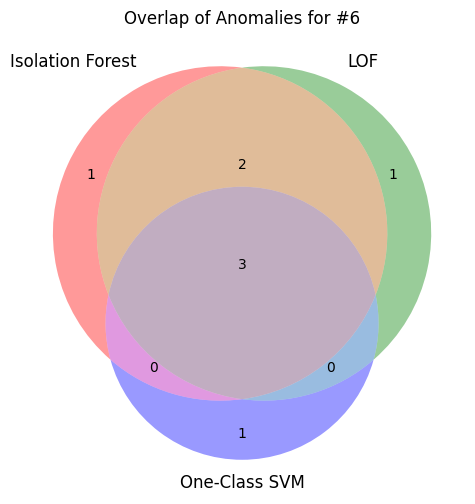

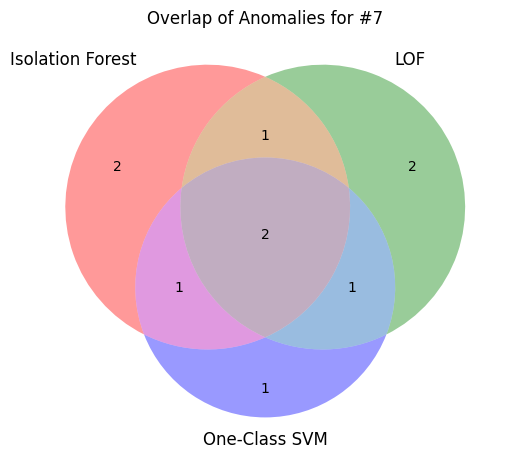

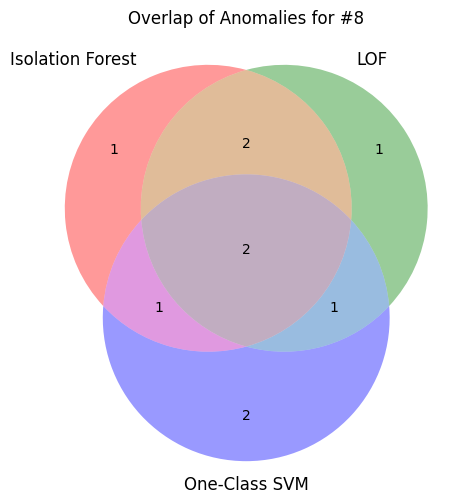

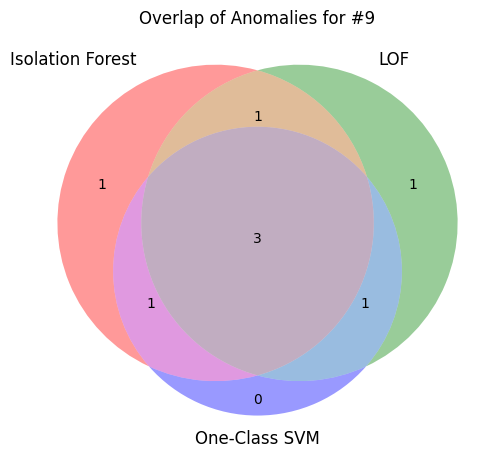

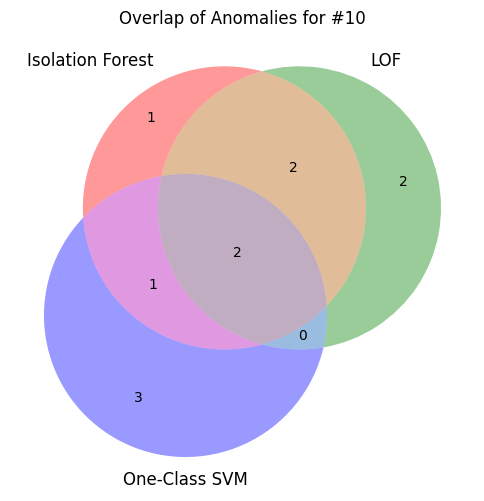

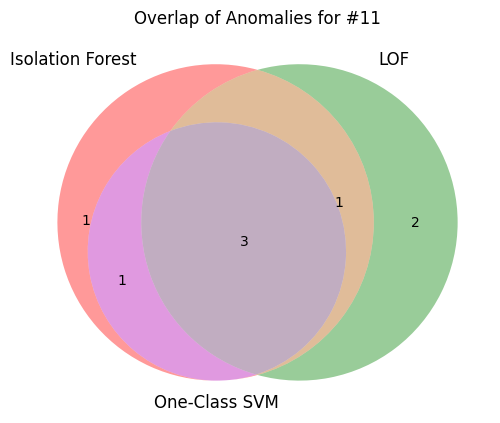

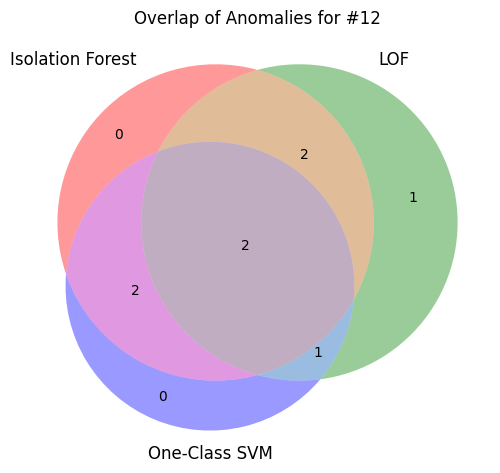

In [14]:
# Ensure necessary libraries are imported
import numpy as np
from matplotlib_venn import venn3
import matplotlib.pyplot as plt

for company, results in anomaly_results.items():
    # Check if LOF and SVM labels are available in the results
    if "LOF_labels" not in results or "SVM_labels" not in results:
        print(f"Missing labels for {company}. Skipping.")
        continue

    # Identify anomaly indices for each method
    company_index = list(company_columns.keys()).index(company) + 1  # Adding 1 for human-readable indexing
    isolation_anomalies = set(np.where(results["anomalies"])[0])
    lof_anomalies = set(np.where(results["LOF_labels"] == -1)[0])
    svm_anomalies = set(np.where(results["SVM_labels"] == -1)[0])

    # Generate the Venn diagram
    plt.figure(figsize=(6, 6))
    venn3([isolation_anomalies, lof_anomalies, svm_anomalies],
          set_labels=("Isolation Forest", "LOF", "One-Class SVM"))
    plt.title(f"Overlap of Anomalies for #{company_index}")
    plt.show()


In [15]:
# Initialize a list to store summary rows
summary_data = []

# Iterate over results and collect anomaly counts for each model
for company, results in anomaly_results.items():
    # Get the index of the current company
    company_index = list(anomaly_results.keys()).index(company) + 1  # Adding 1 for human-readable indexing

    if "LOF_labels" not in results or "SVM_labels" not in results:
        print(f"Missing labels for {company}. Skipping.")
        continue

    # Collect anomaly counts for each detection model
    isolation_count = sum(results["anomalies"])  # Assuming this is a boolean array
    lof_count = sum(np.array(results["LOF_labels"]) == -1)
    svm_count = sum(np.array(results["SVM_labels"]) == -1)

    summary_data.append({
        "Company Index": company_index,  # Add the company index
        "IsolationForest": isolation_count,
        "LOF": lof_count,
        "OneClassSVM": svm_count
    })

# Convert the list of dictionaries to a DataFrame
summary_df = pd.DataFrame(summary_data)

# Sort by company index for clarity (optional)
summary_df = summary_df.sort_values(by="Company Index").reset_index(drop=True)

# Display the summary
from IPython.display import display
display(summary_df)  # Cleaner table view in Colab





,Company Index,IsolationForest,LOF,OneClassSVM
0,1,6,6,5
1,2,6,6,6
2,3,6,6,6
3,4,6,6,8
4,5,6,6,7
5,6,6,6,4
6,7,6,6,5
7,8,6,6,6
8,9,6,6,5
9,10,6,6,6
